# Chemistry modeling

In chemistry, theoretical models are used to rationalize and better understand a wide range of phenomena. We will put a few selected methods in context via application examples and individual lab work to show how they can be used to address concrete chemical questions.

Chemistry modeling is conducted with the use of software programs. In this course, we will apply the Python-driven software package [VeloxChem](https://veloxchem.org/docs/intro.html) {cite}`veloxchem`.

(sec:qc)= 
## Quantum chemistry

Quantum chemistry solves the equations of quantum mechanics to model molecular systems, or more specifically, the electrons in the system. The nuclei, on the other hand, are treated as point charges creating an attractive potential for the electrons.

The differential equation of quantum mechanics are turned into matrix equations suitable for operations on computers by introducing a basis set. Typically one adopts localized atomic orbitals for this purpose that are predefined and tabulated. Very many basis sets are available to serve as computational cost efficient alternatives for different modeling purposes. 

### Simulating IR spectra

The workflow for simulating the IR spectrum of the water molecule is presented below, inspired by the example in [eChem](https://kthpanor.github.io/echem/docs/tutorials/vib_ir_calc.html). The workflow consists of the following steps:

1. Import the VeloxChem module
2. Define a molecule and choose basis set
3. Optimize the electronic structure for the starting geometry
4. Optimize the molecular structure
5. Run a vibrational analysis to get normal modes and IR intensities
6. Plot the IR spectrum

In [1]:
import veloxchem as vlx

In [ ]:
molecule = vlx.Molecule.read_name("water")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

In [ ]:
scf_drv = vlx.ScfRestrictedDriver()

scf_drv.xcfun = "blyp"
scf_drv.ri_coulomb = True

scf_results = scf_drv.compute(molecule, basis)

In [ ]:
opt_drv = vlx.OptimizationDriver(scf_drv)

opt_results = opt_drv.compute(molecule, basis, scf_results)

In [ ]:
opt_molecule = vlx.Molecule.read_xyz_string(opt_results['final_geometry'])

In [ ]:
vib_analysis = vlx.VibrationalAnalysis(scf_drv)

vib_analysis_results = vib_analysis.compute(opt_molecule, basis)

In [ ]:
vib_analysis.plot(vib_results=vib_analysis_results)

Below follows an excerpt from the program output presenting data for the three vibrational modes of water (angle bend, symmetric stretch, and asymmetric stretch):

```
                                                  Vibrational Analysis                                                   
                                                  ======================                                                  
                                                                                                                          
                                   Vibrational Mode      1                                                                
                                   ----------------------------------------------------                                   
                                   Harmonic frequency:                1612.83  cm**-1                                     
                                   Reduced mass:                       1.0819  amu                                        
                                   Force constant:                     1.6581  mdyne/A                                    
                                   IR intensity:                      45.2095  km/mol                                     
                                   Normal mode:                                                                           
                                                              X           Y           Z                                   
                                   1       O            -0.0089     -0.0402      0.0569                                   
                                   2       H            -0.3204      0.2034     -0.5946                                   
                                   3       H             0.4623      0.4347     -0.3079                                   
                                                                                                                          
                                                                                                                          
                                   Vibrational Mode      2                                                                
                                   ----------------------------------------------------                                   
                                   Harmonic frequency:                3632.29  cm**-1                                     
                                   Reduced mass:                       1.0462  amu                                        
                                   Force constant:                     8.1326  mdyne/A                                    
                                   IR intensity:                       0.6656  km/mol                                     
                                   Normal mode:                                                                           
                                                              X           Y           Z                                   
                                   1       O             0.0064      0.0289     -0.0409                                   
                                   2       H            -0.5769     -0.3848      0.1318                                   
                                   3       H             0.4752     -0.0741      0.5175                                   
                                                                                                                          
                                                                                                                          
                                   Vibrational Mode      3                                                                
                                   ----------------------------------------------------                                   
                                   Harmonic frequency:                3726.63  cm**-1                                     
                                   Reduced mass:                       1.0796  amu                                        
                                   Force constant:                     8.8338  mdyne/A                                    
                                   IR intensity:                      12.2127  km/mol                                     
                                   Normal mode:                                                                           
                                                              X           Y           Z                                   
                                   1       O            -0.0625     -0.0185     -0.0229                                   
                                   2       H             0.5531      0.4008     -0.1774                                   
                                   3       H             0.4397     -0.1072      0.5407                                   
```

(sec:md)=
## Molecular dynamics

Quantum chemical calculations are computationally costly and are limited to systems with up to about 1,000 atoms on a supercomputer. Even a small piece of protein from the human body can consist of several thousands of atoms which is beyond reach without further approximations. 

The simulation of large proteins and long time-scales can be achieved using molecular dynamics (MD), in which atoms are the smallest entities to be treated as classical particles bonded together with simple analytical potentials known as force fields. Newtonian mechanics is adopted to simulate the dynamics of the system, typically at a given temperature that is maintained with use of a thermostat. 

In this model, the electronic state cannot change and bonds cannot be broken or formed. So photon absorption/emission or chemical reactions cannot be modeled. Instead the aim is to model molecular structure variations over time.

On a supercomputer, MD simulations can be performed for systems with up to about 1,000,000 atoms over microsecond timescales.

### Modeling room temperature dynamics

First you need to create the system. We will consider a simple case of a single molecule in the absence of a solvent or other environment.

In [2]:
molecule = vlx.Molecule.read_name("gaba")

Reading gaba from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.



In [3]:
molecule.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Next, we need to assign all the bonded and non-bonded interactions between the atoms, i.e., the force field.  This is done with the `MMForceFieldGenerator` class. 

In [4]:
ff_gen = vlx.MMForceFieldGenerator()

ff_gen.create_topology(molecule)

* Info * Using 6-31G* basis set for RESP charges...                                                                       
* Info * Sum of partial charges is not a whole number.                                                                    
* Info * Compensating by removing -1.000e-06 from the largest charge.                                                     
                                                                                                                          
* Info * Using GAFF (v2.11) parameters.                                                                                   
         Reference: J. Wang, R. M. Wolf, J. W. Caldwell, P. A. Kollman, D. A. Case, J. Comput. Chem. 2004,
         25, 1157-1174.
                                                                                                                          
* Info * Updated bond angle 3-5-12 (c -oh-ho) to 120.843 deg                                                              


Now we have everything to start an MD simulation using the `OpenMMDynamics` class.

We run a simulation at 300 K and a pressure of 1 bar for 0.1 ns. The propagation of Newton's equation is made in 100,000 time steps separated by 1 fs, and 50 structures (snapshots) are saved to a file.

In [7]:
opm_dyn = vlx.OpenMMDynamics()

opm_dyn.create_system_from_molecule(molecule, ff_gen)

opm_dyn.run_md(
    ensemble="NVT",
    temperature=300,
    pressure=1.0,
    nsteps=100000,
    timestep=1.0,
    snapshots=50
)

* Info * System parameters written to residue_system.xml                                                                  
* Info * System coordinates written to residue_system.pdb                                                                 
MD Simulation parameters:
Ensemble: NVT
Temperature: 300 K
Friction: 1.0 1/ps
Timestep: 1.0 fs
Total simulation time in ns: 0.1
Step: 0 / 100000 Time: 0.0 ps
Potential Energy -150.1831512451172 kJ/mol
Kinetic Energy: 63.78603744506836 kJ/mol
Temperature: 393.4203560185579 K
Total Energy: -86.39711380004883 kJ/mol
------------------------------------------------------------
Step: 2000 / 100000 Time: 2.0 ps
Potential Energy -127.39120483398438 kJ/mol
Kinetic Energy: 43.20432662963867 kJ/mol
Temperature: 266.4762108606054 K
Total Energy: -84.1868782043457 kJ/mol
------------------------------------------------------------
Step: 4000 / 100000 Time: 4.0 ps
Potential Energy -104.09722328186035 kJ/mol
Kinetic Energy: 40.41972732543945 kJ/mol
Temperatu

Finally you can visualize the structures that were saved using the `visualize_trajectory` function. The interval variable sets the number of milliseconds in between showing saved structures.

In [8]:
opm_dyn.visualize_trajectory(interval=100)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

We can plot the energy of the system for the saved snapshots. The energy is not constant in an MD simulation adopting an *NVT* ensemble but rather controlled by the thermostat.

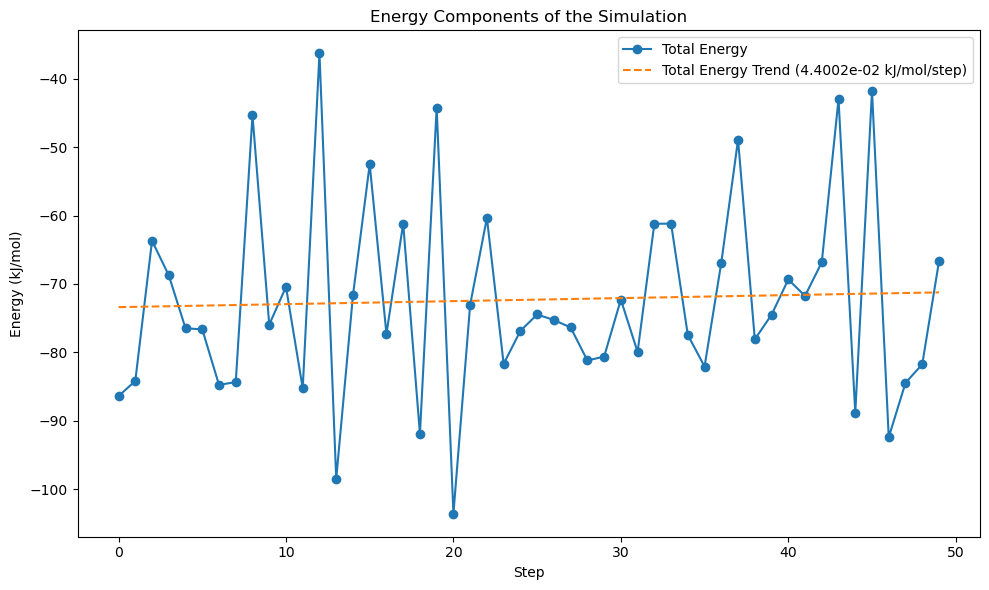

In [9]:
opm_dyn.plot_energy()